In [64]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report, 
    RocCurveDisplay
)

In [65]:
df = pd.read_csv("https://raw.githubusercontent.com/luiseduaardo/ml-ds/refs/heads/main/data/diabetes/diabetes.csv")
df.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,tested_positive
1,1,85,66,29,0,26.6,0.351,31,tested_negative
2,8,183,64,0,0,23.3,0.672,32,tested_positive
3,1,89,66,23,94,28.1,0.167,21,tested_negative
4,0,137,40,35,168,43.1,2.288,33,tested_positive


### Análise de atributos

Não está sendo uma EDA ou preprocessing propriamente dito, mas faz um tratamento e análise básica do estado do dataset.

In [66]:
# Alterando nome das colunas para melhorar legibilidade
df.columns = ["pregnancies", "glucose", "bloodPressure", "skinThickness", "insulin", "bmi", "diabetesPedigreeFunction", "age", "class"]

In [67]:
# Verificando a existência de valores ausentes
df.isna().sum()

pregnancies                 0
glucose                     0
bloodPressure               0
skinThickness               0
insulin                     0
bmi                         0
diabetesPedigreeFunction    0
age                         0
class                       0
dtype: int64

In [68]:
# Altera o tipo de dado do target para inteiro booleano (0 representa testado negativo; 1 representa testado positivo)
df["class"] = df["class"].apply(lambda x: 1 if "positive" in x else 0)

### Treinamento do modelo

In [69]:
# Separação dos dados do modelo em treino e teste
X = df.drop(columns="class")
y = df["class"]

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
# Cria uma pipeline para o modelo
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced'))
])

In [71]:
# Validação cruzada e treinamento do modelo
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    estimator=pipeline,
    X=X_train,
    y=Y_train,
    cv=cv,
    scoring='f1'
)

pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['pregnancies','glucose','bloodPressure',...,'bmi', 'diabetesPedigreeFunction','age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


### Inferência com dados de teste

In [72]:
# Realiza a predição
Y_pred = pipeline.predict(X_test)

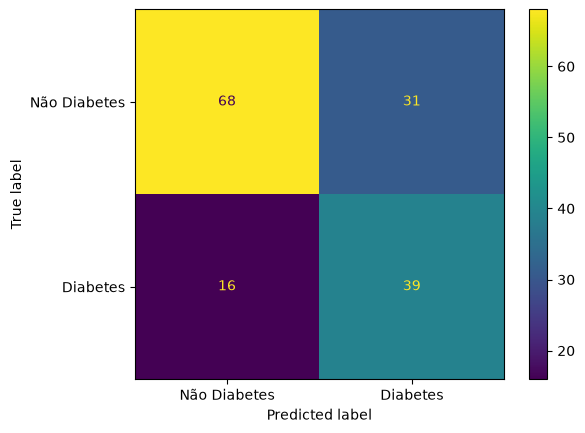

In [73]:
# Plota matriz de confusão dos resultados de teste
cm = confusion_matrix(y_true=Y_test, y_pred=Y_pred)

ConfusionMatrixDisplay(
    cm,
    display_labels=["Não Diabetes", "Diabetes"]
).plot()

In [74]:
# Report de classificação com métricas de avaliação
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.81      0.69      0.74        99
           1       0.56      0.71      0.62        55

    accuracy                           0.69       154
   macro avg       0.68      0.70      0.68       154
weighted avg       0.72      0.69      0.70       154



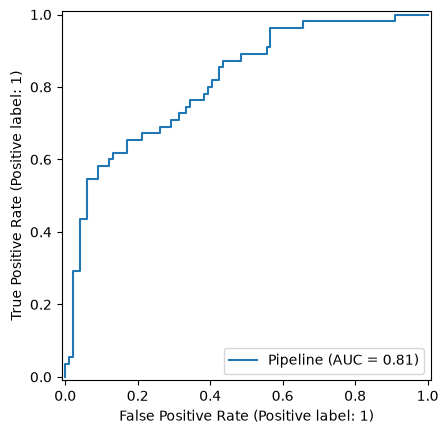

In [75]:
# Plota curva ROC e calcula área abaixo da curva
RocCurveDisplay.from_estimator(
    pipeline,
    X_test,
    Y_test
)